In [13]:
import cv2

img = cv2.imread('./images/input.jpeg')

print("Type of img:", type(img))

cv2.imshow('Input image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

Type of img: <class 'numpy.ndarray'>


In [15]:
gray_img = cv2.imread('./images/input.jpeg', cv2.IMREAD_GRAYSCALE)

cv2.imshow('Grayscale', gray_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [16]:
cv2.imwrite('./images/output.jpg', gray_img)
print("Image saved successfully as images/output.jpg")

Image saved successfully as images/output.jpg


In [17]:
gray_img_converted = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2.imshow('Grayscale image', gray_img_converted)
cv2.waitKey(0)
cv2.destroyAllWindows()

color_flags = [x for x in dir(cv2) if x.startswith('COLOR_')]
print(f"Total available color flags: {len(color_flags)}")
print("Sample color flags:", color_flags[:10])

yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

cv2.imshow('Y channel', yuv_img[:, :, 0])
cv2.imshow('U channel', yuv_img[:, :, 1])
cv2.imshow('V channel', yuv_img[:, :, 2])
cv2.waitKey(0)
cv2.destroyAllWindows()

Total available color flags: 374
Sample color flags: ['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR']


In [18]:
import numpy as np

h, w = img.shape[:2]

new_w, new_h = int(w * 1.5), int(h * 1.5)
scaled_img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)

center = (w // 2, h // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated_img = cv2.warpAffine(img, rotation_matrix, (w, h))

sh_x = 0.2
sh_y = 0.1
shear_matrix = np.float32([
    [1, sh_x, 0],
    [sh_y, 1, 0]
])
sheared_w = int(w + abs(sh_x) * h)
sheared_h = int(h + abs(sh_y) * w)
sheared_img = cv2.warpAffine(img, shear_matrix, (sheared_w, sheared_h))

cv2.imshow('Scaled Image (Increased Size)', scaled_img)
cv2.imshow('Rotated Image (120 Degrees)', rotated_img)
cv2.imshow('Sheared Image', sheared_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.imwrite('./images/task1_scaled.jpg', scaled_img)
cv2.imwrite('./images/task1_rotated.jpg', rotated_img)
cv2.imwrite('./images/task1_sheared.jpg', sheared_img)

True

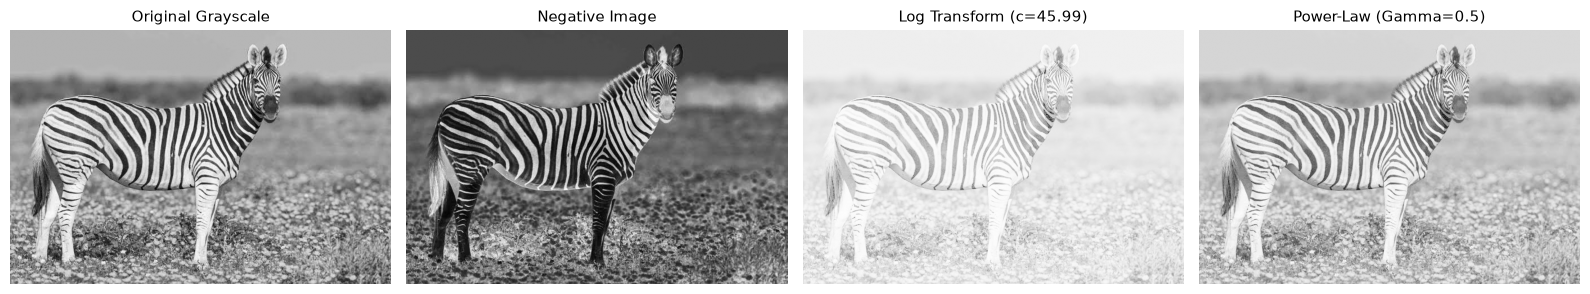

True

In [19]:
import matplotlib.pyplot as plt

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

negative_img = 255 - gray

c_log = 255.0 / np.log(1.0 + float(np.max(gray)))
log_img = c_log * np.log(1.0 + gray.astype(np.float64))
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

gamma = 0.5
gamma_norm = gray / 255.0
gamma_img = np.clip(255.0 * (gamma_norm ** gamma), 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
titles = [
    'Original Grayscale',
    'Negative Image',
    f'Log Transform (c={c_log:.2f})',
    f'Power-Law (Gamma={gamma})'
]
images = [gray, negative_img, log_img, gamma_img]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

cv2.imwrite('./images/task2_negative.jpg', negative_img)
cv2.imwrite('./images/task2_log.jpg', log_img)
cv2.imwrite('./images/task2_gamma.jpg', gamma_img)